In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Load cleaned data
df = pd.read_parquet("../data/processed/loans_clean.parquet")

print(f"Shape: {df.shape}")
print(f"\nLoan status breakdown:")
print(df["loan_status"].value_counts().head(10))

Shape: (2258957, 30)

Loan status breakdown:
loan_status
Fully Paid                                             1076448
Current                                                 877018
Charged Off                                             268488
Late (31-120 days)                                       21443
In Grace Period                                           8427
Late (16-30 days)                                         4344
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


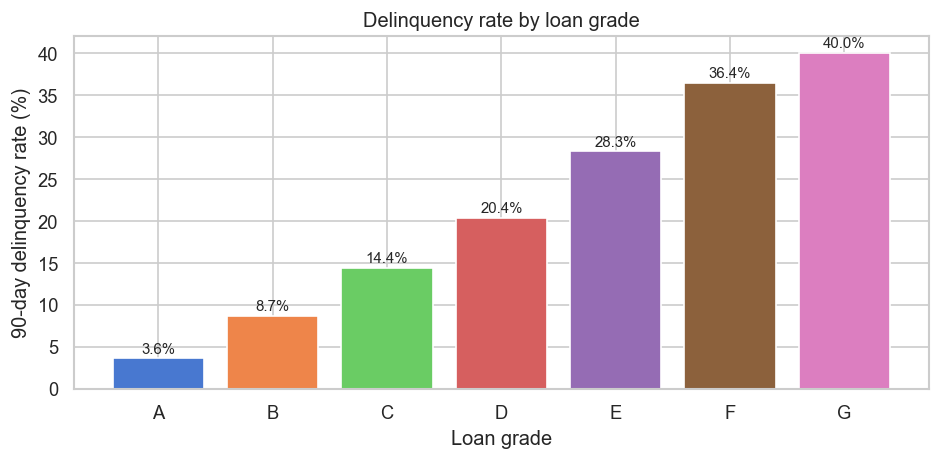

       delq_rate_pct  n_loans
grade                        
A           3.589932   432738
B           8.661479   663120
C          14.366848   649544
D          20.364771   324094
E          28.299075   135538
F          36.438284    41772
G          40.029627    12151


In [2]:
# Delinquency rate by grade
grade_summary = (df.groupby("grade")["delq90"]
                 .agg(["mean", "count"])
                 .rename(columns={"mean": "delq_rate", "count": "n_loans"})
                 .sort_index())

grade_summary["delq_rate_pct"] = grade_summary["delq_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(grade_summary.index, grade_summary["delq_rate_pct"],
              color=sns.color_palette("muted", len(grade_summary)))
ax.set_xlabel("Loan grade")
ax.set_ylabel("90-day delinquency rate (%)")
ax.set_title("Delinquency rate by loan grade")

for bar, val in zip(bars, grade_summary["delq_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../output/figures/delinquency_by_grade.png", dpi=150)
plt.show()

print(grade_summary[["delq_rate_pct", "n_loans"]].to_string())

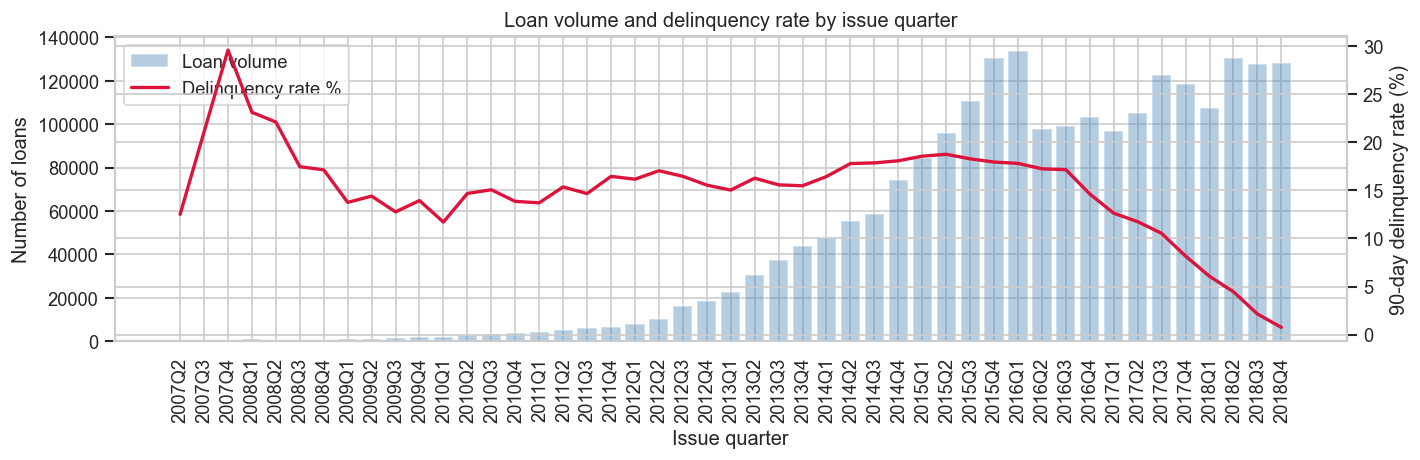

In [3]:
# Loan volume and delinquency rate by issue quarter
quarterly = (df.groupby("issue_quarter")
               .agg(n_loans=("loan_amnt", "count"),
                    delq_rate=("delq90", "mean"),
                    avg_loan=("loan_amnt", "mean"))
               .reset_index())

fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.bar(quarterly["issue_quarter"], quarterly["n_loans"],
        color="steelblue", alpha=0.4, label="Loan volume")
ax1.set_xlabel("Issue quarter")
ax1.set_ylabel("Number of loans")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(quarterly["issue_quarter"], quarterly["delq_rate"] * 100,
         color="crimson", linewidth=2, label="Delinquency rate %")
ax2.set_ylabel("90-day delinquency rate (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Loan volume and delinquency rate by issue quarter")
plt.tight_layout()
plt.savefig("../output/figures/volume_and_delinquency_over_time.png", dpi=150)
plt.show()

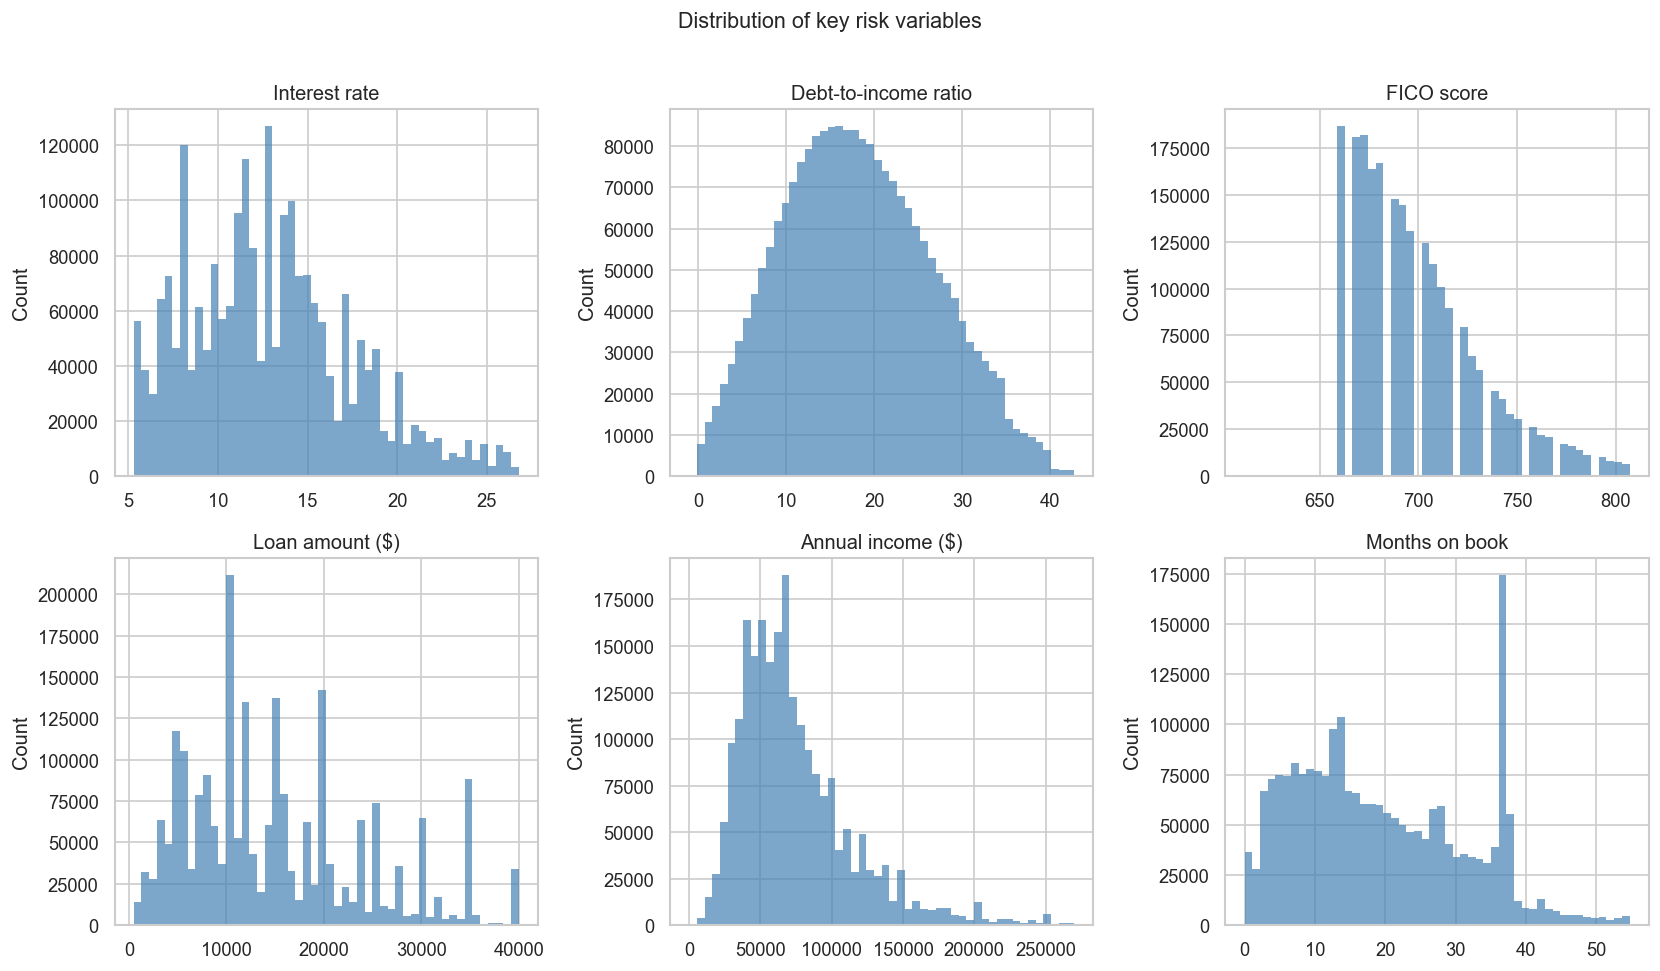

In [4]:
# Distribution of key numeric risk variables
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

vars_to_plot = [
    ("int_rate",   "Interest rate",        lambda x: x * 100),
    ("dti",        "Debt-to-income ratio", lambda x: x),
    ("fico",       "FICO score",           lambda x: x),
    ("loan_amnt",  "Loan amount ($)",      lambda x: x),
    ("annual_inc", "Annual income ($)",    lambda x: x),
    ("months_obs", "Months on book",       lambda x: x),
]

for ax, (col, label, transform) in zip(axes.flat, vars_to_plot):
    data = transform(df[col].dropna())
    # Cap extreme outliers for cleaner plots
    p99 = data.quantile(0.99)
    data = data[data <= p99]
    ax.hist(data, bins=50, color="steelblue", alpha=0.7, edgecolor="none")
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.suptitle("Distribution of key risk variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../output/figures/variable_distributions.png", dpi=150)
plt.show()

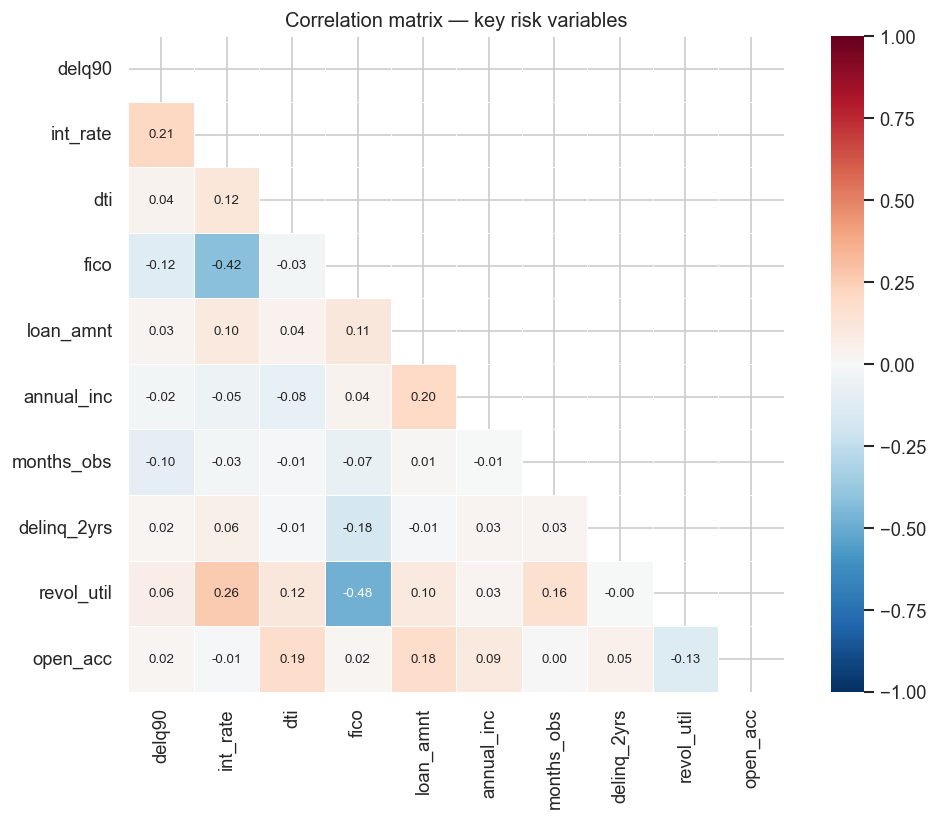

In [5]:
# Correlation heatmap of numeric risk variables
corr_cols = ["delq90", "int_rate", "dti", "fico", 
             "loan_amnt", "annual_inc", "months_obs",
             "delinq_2yrs", "revol_util", "open_acc"]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})

ax.set_title("Correlation matrix — key risk variables")
plt.tight_layout()
plt.savefig("../output/figures/correlation_heatmap.png", dpi=150)
plt.show()

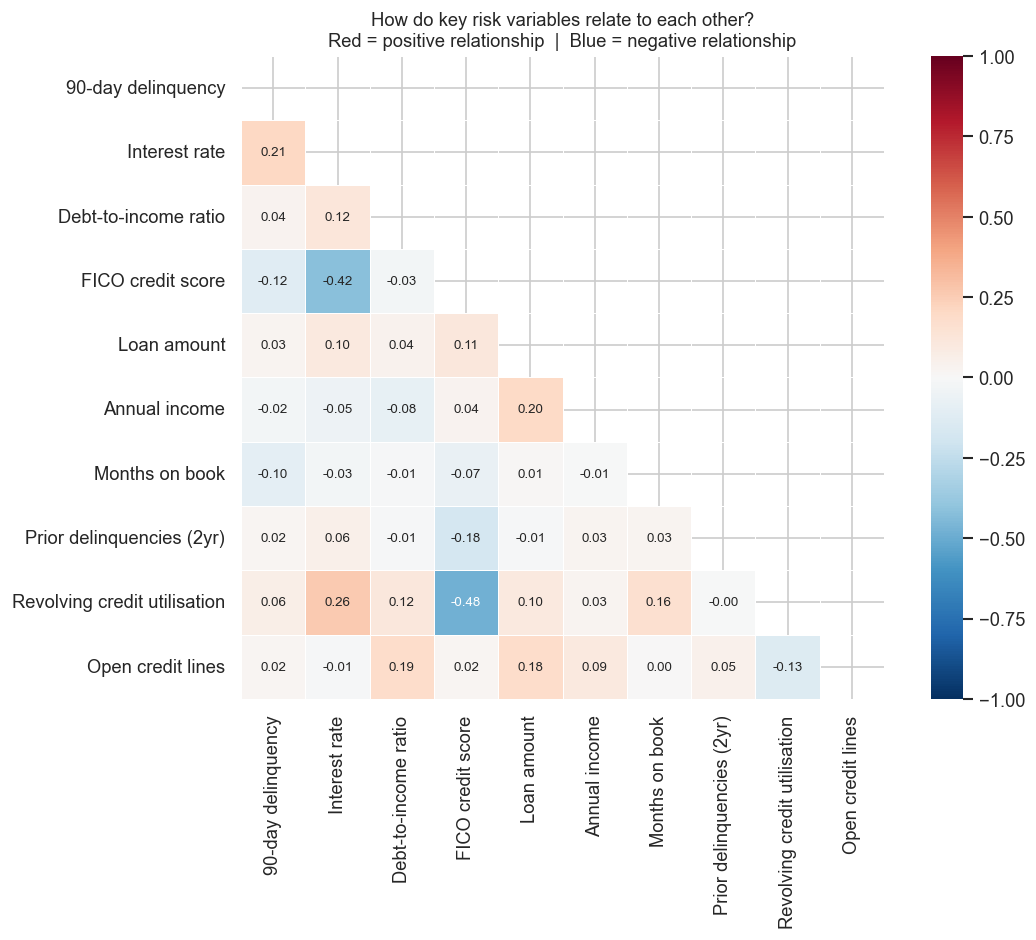

In [6]:
# ── Regenerate correlation heatmap with clean labels ─────────────────────────
label_map = {
    "delq90":       "90-day delinquency",
    "int_rate":     "Interest rate",
    "dti":          "Debt-to-income ratio",
    "fico":         "FICO credit score",
    "loan_amnt":    "Loan amount",
    "annual_inc":   "Annual income",
    "months_obs":   "Months on book",
    "delinq_2yrs":  "Prior delinquencies (2yr)",
    "revol_util":   "Revolving credit utilisation",
    "open_acc":     "Open credit lines",
}

corr_cols = list(label_map.keys())
corr = df[corr_cols].corr()
corr.index   = list(label_map.values())
corr.columns = list(label_map.values())

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})

ax.set_title("How do key risk variables relate to each other?\n"
             "Red = positive relationship  |  Blue = negative relationship",
             fontsize=11)
plt.tight_layout()
plt.savefig("../output/figures/correlation_heatmap.png", dpi=150)
plt.show()